# TailRisk Solutions: Data-Driven Strategies for Financial Resilience in Energy Procurement
**Course:** 42578 Advanced Business Analytics | Technical University of Denmark (DTU)  
**Theme:** Intelligent Methods for Resilience  
**Group:** 17  
**Consultants:** Ignacio Ripoll s242875, Pablo Baurier s253159 & Alejandro López s253272

---

## Executive Summary
This project develops an advanced Decision Support System (DSS) for industrial manufacturers to mitigate financial exposure in the Iberian Electricity Market (MIBEL). Energy procurement is traditionally treated as a binary choice: either lock in long-term fixed contracts (sacrificing flexibility) or purchase daily on the Spot market (incurring catastrophic tail risks). 

**TailRisk Solutions** introduces a hybrid strategy: **Baseload Hedging combined with Operational Peak-Shaving**. 
Our framework splits the factory's energy demand into two layers:
1.  **Financial Resilience (Long-Term):** Securing the factory's "must-run" baseline production using OMIP Monthly Futures (M1 to M6), locking in costs and neutralizing extreme market spikes.
2.  **Operational Flexibility (Short-Term):** Leaving discretionary production capacity exposed to the Day-Ahead market. Utilizing a Reinforcement Learning agent, the DSS evaluates tomorrow's deterministic price ($t+1$) against the stochastic forecasts for the following 48-72 hours ($t+2$ and $t+3$). The agent dynamically shifts this discretionary production—overproducing during cheap renewable energy gluts and halting discretionary lines during price peaks.

This report details the end-to-end pipeline, from integrating heterogeneous financial and meteorological data streams to engineering market-spread features, culminating in a resilient, dual-action Reinforcement Learning environment.

---

## Technical Preface: The Iterative Path to Resilience
While this report presents a streamlined and cohesive analytical narrative, it is the result of an extensive iterative process. Behind every "clean" data ingestion and "synchronized" merge shown here, there were multiple stages of data auditing, exploratory trial-and-error, and the rejection of sub-optimal features. 

We have intentionally omitted the exhaustive "sandbox" explorations to maintain clarity and focus on the final Decision Support System's logic. This report represents the refined distillation of our findings, prioritizing the "story of the data" over the raw complexity of the journey. For a deeper look into our initial hypotheses and failed prototypes, please refer to the auxiliary exploratory notebooks in the `/notebooks` directory.

The complete modular codebase, including all exploratory "sandbox" notebooks, source scripts, and the full project structure, is available at our official repository: **[TailRisk Solutions: Project Repository](https://github.com/TuUsuario/alopezberm/Data-Driven-Strategies-for-Financial-Resilience-in-Energy-Procurement)**

---

## Table of Contents
1.  **Section 0: Environment Setup & Dependencies**
    * 0.1 Prerequisites
    * 0.2 Master Dependencies & Environment Setup
2.  **Section 1: Business Context & The Dual-Layer Strategy**
    * 1.1 The Market Architecture
    * 1.2 Layer 1: Baseload Risk Mitigation
    * 1.3 Layer 2: Discretionary Production Shifting
    * 1.4 Modeling Assumption: Daily Baseload Price
    * 1.5 Modeling Assumption: Financial Action Space
3.  **Section 2: Data Engineering**
    * 2.1 Financial Data Acquisition: Web Scraping
    * 2.2 Meteorological Data Acquisition: API Architecture
    * 2.3 Financial EDA: Market Dynamics & Risks
    * 2.4 Meteorological EDA: Weather Trends
4.  **Section 3: Data Preprocessing & The Master Merge**
    * 3.1 Financial Data Quality & Calendar Integration
    * 3.2 Meteorological Refinement
    * 3.3 The Master Merge: Building the Decision Matrix
5.  **Section 4: Feature Engineering**
    * 4.1 Statistical Synergy & State-Space Validation
    * 4.2 Engineering the AI Memory & Physical Triggers
    * 4.3 Dimensionality Reduction and Feature Selection
6.  **Section 5: Predictive Modeling & Risk Assessment**
    * 5.1 Baseline Forecast
    * 5.2 Quantile Regression
    * 5.3 Tail Risk Model
    * 5.4 Model Comparison
7.  **Section 6: The Decision Engine (Reinforcement Learning)**
8.  **Section 7: Counterfactual Backtesting & Results**
9.  **Section 8: Strategic Recommendations**

---

## 0. Environment Setup & Dependencies

### 0.1 Prerequisites
To ensure reproducibility, install the necessary dependencies using the `requirements.txt` file located in the project root:

```bash
pip install -r ../requirements.txt


### 0.2 Master Dependencies & Environment Setup
To ensure the academic rigor and reproducibility required by DTU standards, all dependencies are centralized. This manifesto includes tools for high-performance data manipulation, statistical visualization, and the machine learning frameworks used for risk quantification.

In [1]:
# 1. System & Operations
import os
import sys
import warnings
import matplotlib.dates as mdates
from datetime import datetime
from pathlib import Path

# 2. Data Manipulation & Numerical Computing
import numpy as np
import pandas as pd

# 3. Visualization Suite (Academic Standard)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go # For interactive financial charts
from IPython.display import display

# 4. Machine Learning & Statistical Tools
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from scipy.ndimage import gaussian_filter1d 

# 5. Reinforcement Learning Foundations
# import gymnasium as gym
# from stable_baselines3 import PPO, DQN

# Environment Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Professional plotting style
%matplotlib inline

# Global Pandas Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Project Constants (Standardized across the pipeline)
TARGET_HORIZONS = [2, 3]  # Optimizing daily shifts for t+2 and t+3
HEDGE_TARGET = 'Future_M1'  # Primary instrument for baseload risk mitigation
RANDOM_SEED = 42    # For reproducibility
print(f"✅ TailRisk Solutions Environment Loaded | Python {sys.version.split()[0]}")

✅ TailRisk Solutions Environment Loaded | Python 3.12.11


---

## 1. Business Context & The Dual-Layer Strategy

### 1.1 The Market Architecture
The Iberian Electricity Market operates across two primary timeframes, both of which are required to build a resilient procurement strategy:
* **OMIP (Derivatives Market):** Where financial futures (Months M1 through M6) are traded. These instruments reflect the macroeconomic expectations of the market and allow consumers to lock in prices months in advance.
* **OMIE (Day-Ahead Spot Market):** A blind auction clearing at 13:00 CET on day $t$ for all 24 hours of day $t+1$. This market is highly volatile, driven by immediate weather conditions (wind/solar generation) and geopolitical gas shocks.

### 1.2 Layer 1: Baseload Risk Mitigation
To prevent operational bankruptcy during sustained energy crises, our strategy establishes a **Baseload Hedge**. A predetermined percentage of the factory's minimum required energy is purchased via OMIP Futures (e.g., locking in a fixed rate for `Future_M1`). This guarantees that the core production line operates at a known, stable cost, immunizing the business against extreme tail risks.

### 1.3 Layer 2: Discretionary Production Shifting
While hedging mitigates risk, it eliminates the opportunity to capitalize on zero-price days driven by renewable overproduction. The remaining, unhedged percentage of our energy demand is managed dynamically by our Decision Support System.

Operating under the OMIE temporal constraints, at 13:00 CET on day $t$, the cost for tomorrow ($t+1$) becomes deterministic. Our RL agent compares this fixed $t+1$ cost against the stochastic forecasts for $t+2$ and $t+3$. 
* **Action - Overproduce:** If $t+1$ is cheap relative to $t+2/t+3$, the factory increases its discretionary production, storing excess inventory using cheap Spot energy.
* **Action - Curtail:** If $t+1$ is expensive, the factory shuts down discretionary lines, relying on inventory and waiting for the cheaper energy forecasted in the coming days.

By treating the factory as a flexible asset acting on the spread between long-term hedges and short-term spot volatility, we achieve true financial resilience.

### 1.4 Modeling Assumption: Daily Baseload Price
To align the analytics with macro-level industrial planning and reduce state-space complexity for the Reinforcement Learning agent, we assume a **Constant Daily Price**. We utilize the daily average (baseload) price as the primary economic signal for the Spot market. This focuses the optimization on the "Day-to-Day" shifting logic rather than intra-day hourly volatility, which often averages out over a full production shift.

### 1.5 Modeling Assumption: Financial Action Space
The OMIP and OMIE markets are highly complex ecosystems offering derivatives at multiple granularities (Intraday, Daily, Weekly, Quarterly, and Yearly). To build a computationally viable state-space for our agent without losing the essence of tail-risk management, we established a strategic scope reduction:
* We restrict the agent's financial action space exclusively to **Monthly Futures (M1 to M6)**. 
* While daily or intraday trading exists, our Decision Support System (DSS) is designed for **structural hedging and business resilience**, not high-frequency speculative trading. This assumption perfectly aligns with standard corporate procurement cycles and ensures the model solves a macro-strategic problem rather than a micro-trading one.

---

## 2. Data Engineering

The robustness of our Decision Support System (DSS) depends fundamentally on the reliability of its data streams. This section details the "Web Data Mining" strategies employed to build our dataset, highlighting how we engineered the ingestion pipelines to be inherently resilient to network failures and strict rate limits.

### 2.1 Financial Data Acquisition: Web Scraping
Unlike standard financial markets, the **OMIP (Iberian Energy Derivatives Exchange)** does not expose a public API for historical settlement data. To overcome this information asymmetry, we developed an automated **Web Scraper** (`src/extraction/extract_omip.py`).
* **Extraction Logic:** The scraper programmatically navigates the OMIP HTML Document Object Model (DOM) to extract daily closing prices for **Spanish Daily Spot Market (SPEL)**, **Monthly Futures (M1 to M6)** and **Open Interest** levels.
* **Analytical Value:** Open Interest acts as a proxy for market liquidity and collective sentiment. Capturing this "dark data" provides our Reinforcement Learning agent with foresight regarding shifts in market positioning that are invisible to price-only models.
* **Temporal Scope:** For this study, the extraction window was configured from **January 1st, 2020, to December 31st, 2024**.This specific timeframe was strategically selected to capture a full cycle of market volatility, encompassing:
    1. The pre-disruption baseline and COVID-19 lockdowns (2020).
    2. The severe European energy crisis and price shocks (2021-2022).
    3. The subsequent market stabilization and adaptation phase (2023-2024).


### 2.2 Meteorological Data Acquisition: API Architecture
While financial data reflects market expectations, weather data dictates the physical reality of energy supply. To capture this, we engineered a highly fault-tolerant ingestion engine (`src/extraction/extract_weather.py`) interacting with the **Open-Meteo Archive API**.

To extract daily historical data (2020-2025) across 52 Spanish provinces without triggering server bans or losing data due to timeouts, we implemented several defensive programming paradigms:
1.  **Geospatial Batching:** Province coordinates (latitude/longitude) are loaded from an external metadata file (`_Provincias_Info.xlsx`) and partitioned into controlled batches (e.g., indices 0-10, 11-51) to strictly respect API payload limits.
2.  **Network Resilience (Caching & Retries):** We integrated `requests_cache` to locally store API responses, preventing redundant network calls during development. Furthermore, we wrapped the HTTP session in a `retry_requests` adapter with an exponential backoff factor. If the Open-Meteo server drops a connection, our pipeline automatically waits and safely reattempts the download, ensuring absolute data completeness.
3.  **National Aggregation:** In downstream processing, these 52 regional time series are weighted and aggregated into a "National Peninsular Index." This smooths localized sensor noise while amplifying macro-climatic events (e.g., severe wind fronts) that directly collapse Iberian spot prices.

In [2]:
# Path resolution for modular imports
if str(Path.cwd().resolve().parents[1]) not in sys.path:
    sys.path.append(str(Path.cwd().resolve().parents[1]))

from src.data.load_raw_data import load_raw_data
print("✅ Modular loaders successfully imported.")

# Execute the Ingestion Pipeline
raw_datasets = load_raw_data()

# Store in explicit variables for the analytical pipeline
df_omip_raw = raw_datasets['omip']
df_weather_raw = raw_datasets['weather']
df_holidays_raw = raw_datasets['holidays']

print(f"\n📊 Ingestion Audit Passed:")
print(f"   - Financial (OMIP): {df_omip_raw.shape[0]} days captured.")
print(f"   - Weather (API):    {df_weather_raw.shape[0]} days captured.")
print(f"   - Holidays:         {df_holidays_raw.shape[0]} days captured.")

✅ Modular loaders successfully imported.

📊 Ingestion Audit Passed:
   - Financial (OMIP): 2192 days captured.
   - Weather (API):    2192 days captured.
   - Holidays:         2192 days captured.


### 2.3 Financial EDA: Market Dynamics & Risks
Conducting an **Exploratory Data Analysis (EDA)** on the OMIP dataset isn't just about describing historical prices; it's about defining the exact "observation space" our Reinforcement Learning agent will use to make decisions. In this section, we break down the market's microstructure to justify our feature engineering and show exactly where the hedging opportunities lie.

In [3]:
from src.visualization.visualize_omip import (plot_market_regimes, plot_volatility_signals, plot_liquidity_sparsity, plot_anticipation_variance)

#### 2.3.1 Market Regimes: Structural Crises vs. Stability
The relationship between the physical Spot price and the immediate Future (M+1) defines the current market regime. 
* **Contango (Green):** When the Future is priced higher than the Spot, the market is paying a "risk premium" for upcoming months. It's a sign of stable, forward-looking expectations.
* **Backwardation (Red):** When the Spot violently overtakes the Future—as we saw during the 2021-2022 Energy Crisis—it signals an immediate physical shortage. For our RL agent, identifying a sudden shift into Backwardation is a critical trigger to execute protective actions.

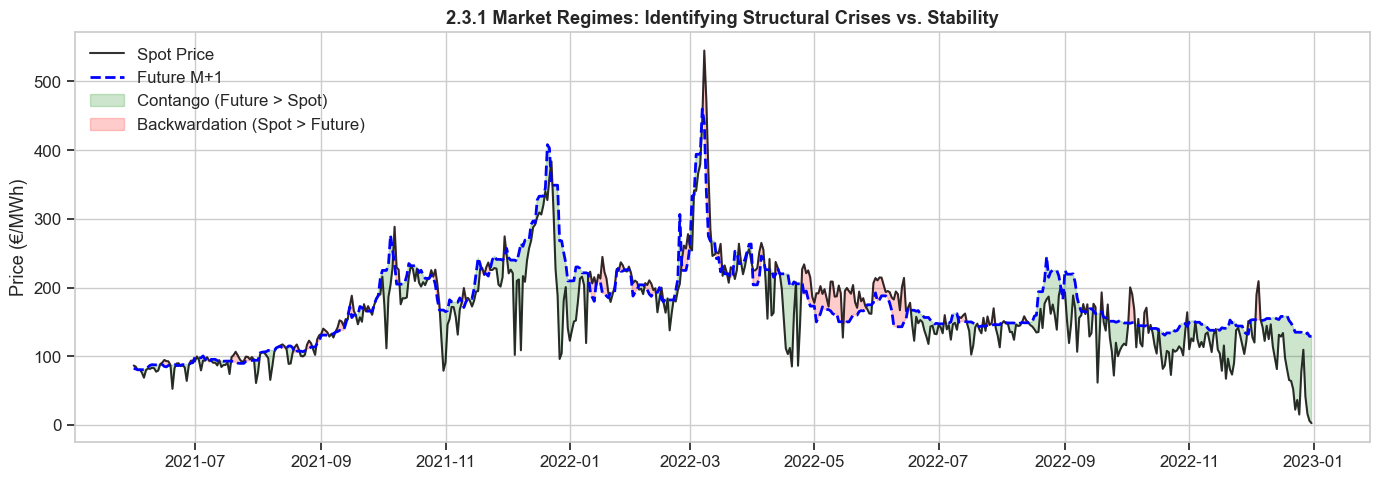

In [4]:
plot_market_regimes(df_omip_raw)

#### 2.3.2 Operational Risk Assessment: Volatility Signals
Absolute prices alone don't capture risk; the *rate of change* does. To help the agent identify risk clusters, we analyzed the rolling standard deviation of the Spot price.
* **Volatility Shocks:** By comparing a fast-reacting signal (7-day volatility) against a structural baseline (30-day volatility), we can detect emerging market panics. When the 7-day volatility sharply crosses the 30-day line (the orange shaded areas), a shock is emerging. We engineer these specific crossovers as core features so the agent learns exactly when to increase its risk-aversion.

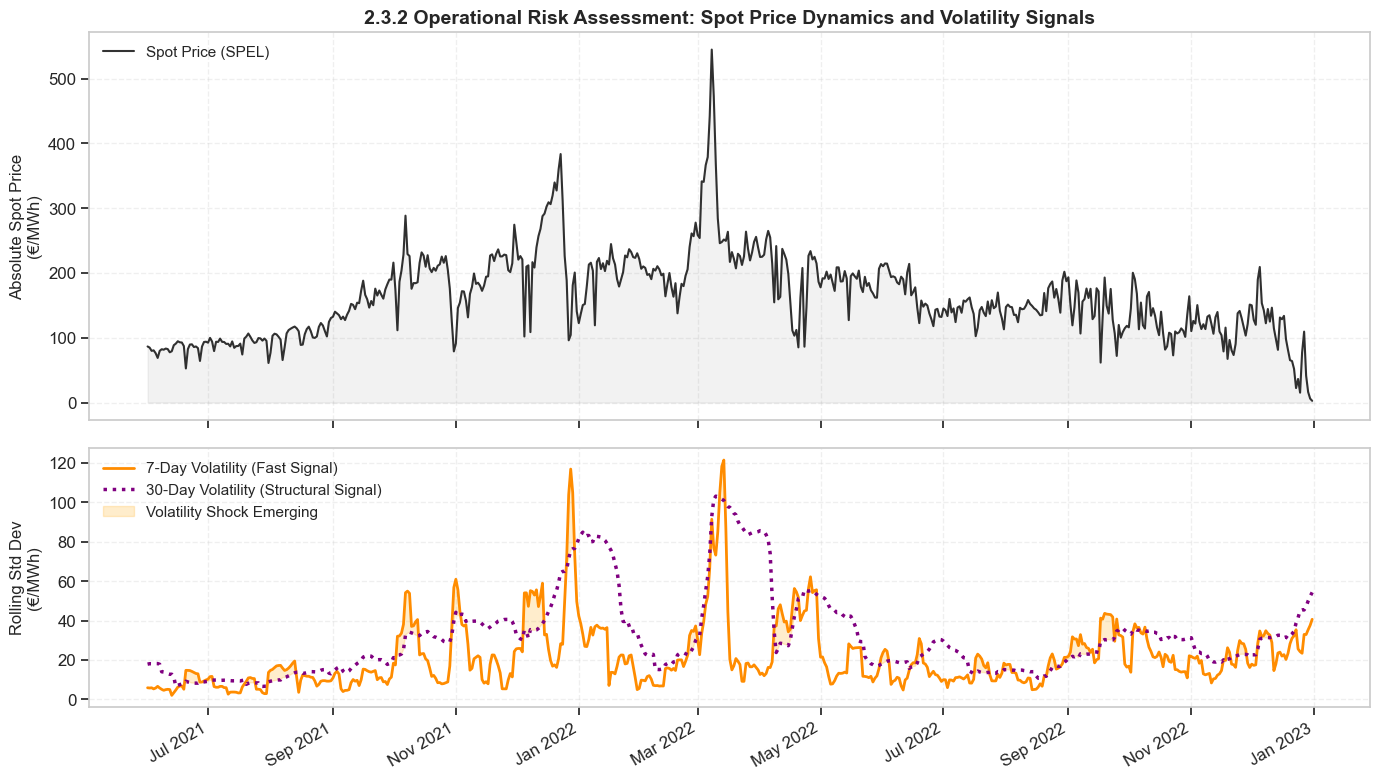

In [5]:
plot_volatility_signals(df_omip_raw)

#### 2.3.3 Market Liquidity: Avoiding the "Ghost Market" Trap
A hedging strategy is useless if you can't actually execute the trade in the real world. We audited the **Open Interest** (active contracts) across the forward curve to see where the real money is.
Our analysis revealed a massive liquidity drop-off. Contracts from M4 to M6 are essentially "ghost markets" where over 50% of the days have zero trading volume. We actively exclude these from the agent's state-space for three critical, real-world reasons:
1. **Slippage:** In illiquid markets, trying to buy protection means paying a massive Bid-Ask spread just to find a seller.
2. **Exit Risk:** If market conditions flip, you cannot sell your position because there is no one on the other side to buy it. 
3. **The AI Data Trap:** If a contract doesn't trade for a week, its price in the dataset stays perfectly flat. To a machine learning model, a flat line looks like a perfectly safe, zero-risk asset. Feeding M6 data to our agent would literally train it to walk into a liquidity trap.

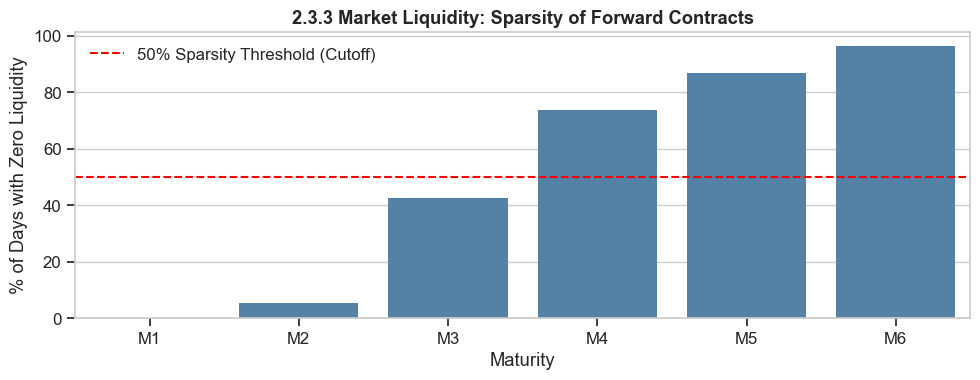


📊 Liquidity Audit Table:


,Maturity,Median_Contracts,Max_Contracts,Sparsity (%)
0,M1,434.0000,1724.0000,0.0500
1,M2,32.0000,1552.0000,5.3800
2,M3,2.0000,1395.0000,42.5600
3,M4,0.0000,54.0000,73.8100
4,M5,0.0000,13.0000,86.9500
5,M6,0.0000,3.0000,96.5300


In [6]:
plot_liquidity_sparsity(df_omip_raw)

#### 2.3.4 Anticipation Variance: The M3 Hedging Opportunity
So, if we exclude the long-term horizons, where is the money made? The answer lies in the **Anticipation Variance** within our longest viable liquid horizon: the M3 contract (90 days out).

This metric tracks the massive gap between what the market predicted 3 months ago and the extreme reality of the Spot price today. 
* **The Opportunity Margin:** The market is historically bad at pricing risk 90 days out. This creates a massive margin. 
* **Strategic Value:** When the variance drops deep into the negative (a Spot spike), a company fully exposed to the spot market bleeds cash. An RL agent that correctly locked in the M3 price earlier would save millions. Conversely, during stable periods, blindly hedging every month incurs a heavy "fear premium." Our DSS uses these massive discrepancies as its primary playground—dynamically shifting between Spot and M3 to optimize the risk-reward ratio and build true financial resilience.

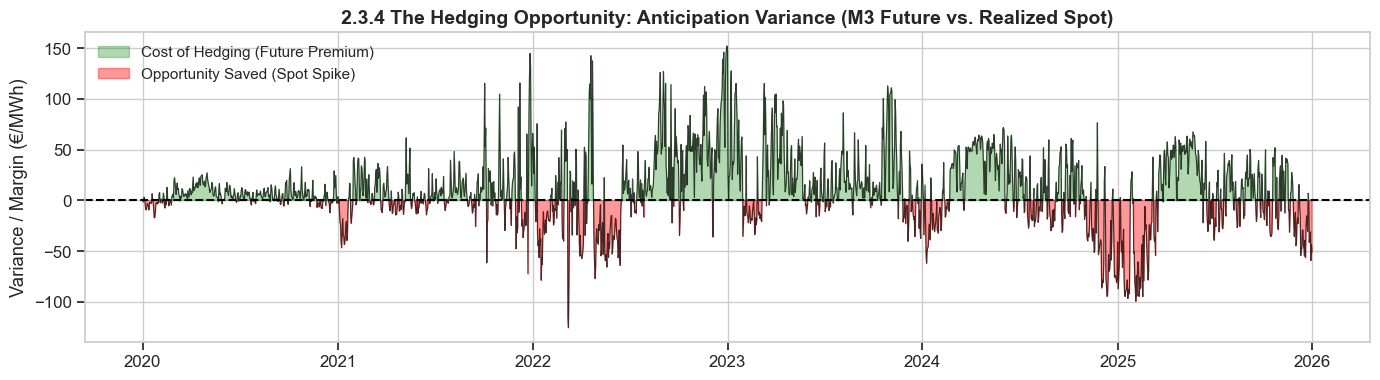

In [7]:
plot_anticipation_variance(df_omip_raw)

### 2.4 Meteorological EDA: Physical Drivers & Renewable Volatility
While the financial data defines our risk in Euros, the meteorological data defines our risk in **physical reality**. In the Iberian market (MIBEL), weather is the ultimate price setter, as it dictates the availability of low-marginal-cost renewable energy.

As established during our technical data preparation and extraction phase, we do not rely on simple national averages. Instead, we utilize a **Generation-Weighted Aggregation logic**. Our meteorological variables (Temperature, Wind, and Solar) are weighted based on the installed generation capacity of each specific region. This ensures that a weather event in a high-production hub (like wind in Galicia or solar in Andalusia) impacts our agent's state-space with the correct proportional intensity, reflecting the true systemic influence of weather on market prices.

In [8]:
from src.visualization.visualize_weather import (plot_thermal_profile, plot_renewable_intermittency, plot_physical_financial_correlation) 

#### 2.4.1 Thermal Seasonality and The "Flaw of Averages"
Temperature is the primary driver of systemic electricity demand. To fully understand its impact on market prices, we must analyze it across two distinct dimensions:

* **Part A: The Expected Baseline (Seasonality):** Using a 30-day rolling average, we define the standard macro-cycle of the Iberian Peninsula. This establishes the predictable base demand.
* **Part B: The Structural Risk (Extremes & Dispersion):** Relying solely on a national average is dangerous in energy procurement—a concept known as the "Flaw of Averages." A comfortable national mean can mask severe localized grid stress. By plotting the Provincial Dispersion (±1 STD) alongside the robust Peninsular Maximums and Minimums, we isolate the exact tail-risk events (Heatwaves and Polar Fronts) that trigger sudden Spot price explosions. These extremes act as critical warning signals for our RL agent.

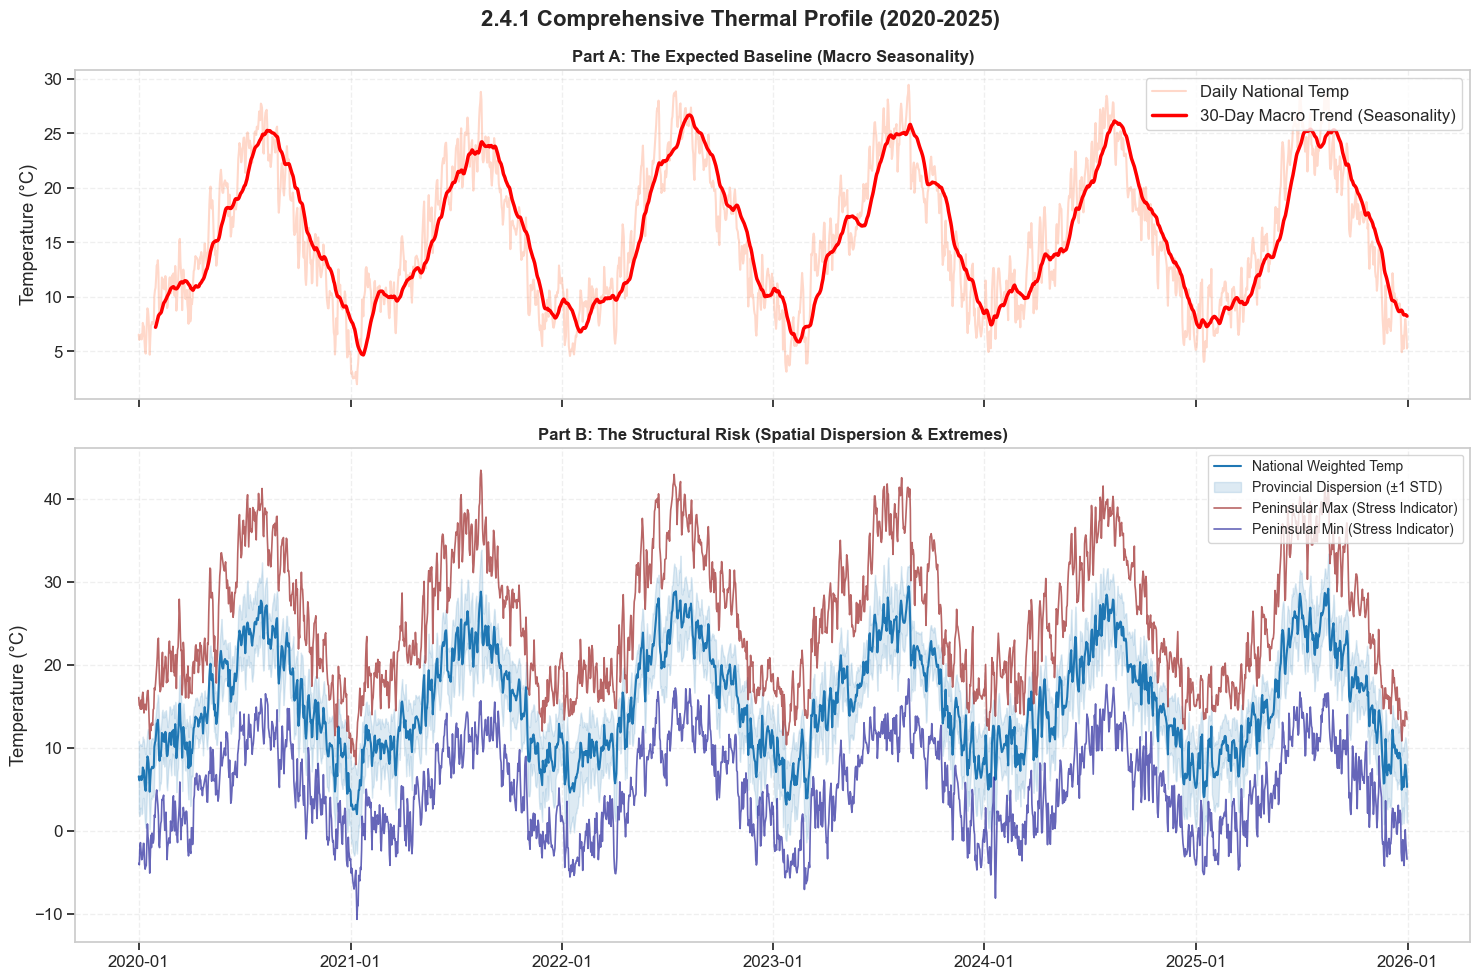

In [9]:
plot_thermal_profile(df_weather_raw)

#### 2.4.2 Renewable Merit Order: Solar & Wind Intermittency
The "Merit Order Effect" is the physical engine of the MIBEL market: when renewable production is high, expensive gas plants are displaced, driving prices down.
* **The "Dunkelflaute" Risk:** The most critical state for our factory is the "dark doldrums" (low wind and low solar). Our EDA focuses on these periods as they are the leading physical indicators of the "Backwardation" (Red) regimes we identified in the financial section.

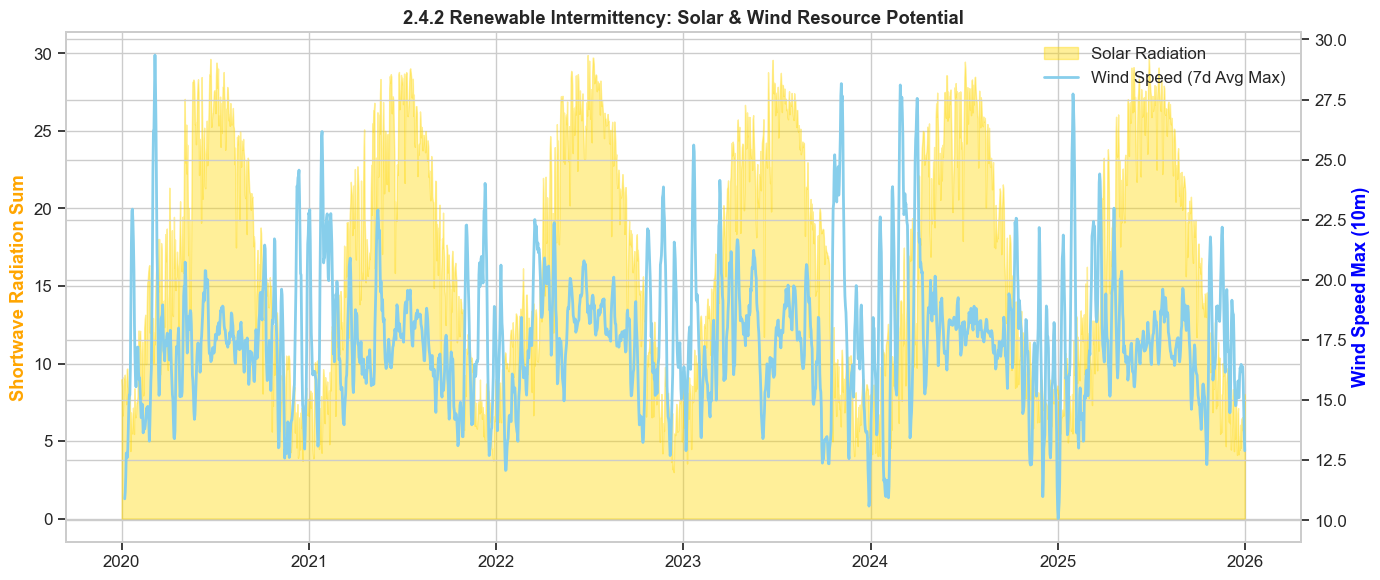

In [10]:
plot_renewable_intermittency(df_weather_raw)

#### 2.4.3 Physical-Financial Coupling: Correlation Insights
The correlation heatmap provides the statistical validation for our state-space design. It quantifies how sensitive the Iberian Spot price is to physical changes in the environment.

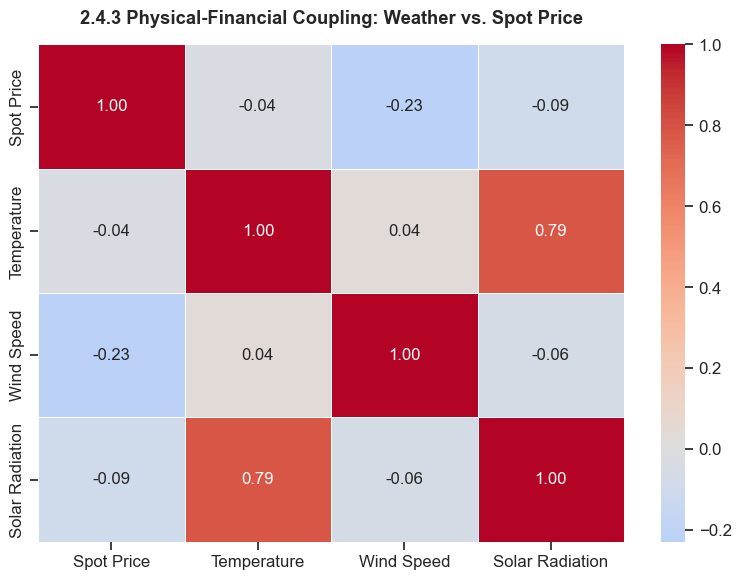

In [11]:
plot_physical_financial_correlation(df_weather_raw, df_omip_raw)


**Key Findings from the Correlation Matrix:**
* **Wind Speed Dominance (-0.23):** We observe a clear inverse correlation between wind speed and the Spot price. This is a mathematical manifestation of the "Merit Order Effect": as wind generation increases, it displaces more expensive marginal technologies (like CCGT), driving prices down. This makes wind speed the most reliable linear "leading indicator" for our RL agent.
* **Solar Radiation (-0.09):** While also inversely correlated, solar radiation shows a milder linear impact. This reflects the market's daily profile: while solar energy lowers prices during midday, peak volatility and high prices often occur during the "sunset ramp-up," when solar contribution drops but grid demand remains extremely high.
* **The Temperature Paradox (-0.04):** The near-zero linear correlation for temperature is a classic statistical trap and reveals a strongly non-linear relationship. Prices do not trend in a straight line with temperature; instead, they spike violently at both thermal extremes (extreme cold fronts and summer heatwaves). 

**Conclusion for Model Design:**
These empirical values justify our architectural decisions. The RL agent must process wind and solar as direct price-suppression signals, while treating temperature not as a linear variable, but as a threshold-based "regime-shift" indicator that triggers extreme tail-risk protocols.

# 3. Data Preprocessing

Once the exploratory phase is complete, we transition into the technical pipeline. This stage ensures that our diverse datasets (Financial, Meteorological, and Calendar) are synchronized and structurally sound before the Reinforcement Learning agent begins its training.

In [12]:
PROJECT_ROOT = Path.cwd().resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.clean_omip import clean_omip_data
from src.data.clean_weather import clean_weather_data
from src.data.clean_holidays import clean_holidays_data
from src.config.constants import DATE_COLUMN

### 3.1 Financial Data Quality & Calendar Integration
In the OMIP dataset, a critical audit revealed a structural gap: exactly one missing value on January 1st across all Futures and Open Interest columns, while the Spot market (OMIE) remained complete.

* **The Business Reality:** This is not a technical error, but a structural market reality. The Spot market operates 365 days a year, but the OMIP is a financial exchange that closes on public holidays (such as New Year's Day).

* **Architectural Decision:** We intentionally avoid generic interpolation. Instead, we preserve the gap to be handled via a backward-fill (bfill) strategy. Moreover, we implemented this strategy to all the other non-working days in our dataframe. For that, we integrated a specialized Holidays dataset. This ensures that the agent’s initial state remains consistent with the first available trading day without altering financial history.

* **Strategic Impact:** Beyond data cleaning, the holiday calendar serves as a vital feature. Electricity demand is not purely driven by weather; it is heavily dictated by human activity cycles. Holidays act as a "Regime Shift" signal; providing this "Calendar Context" prevents the RL agent from confusing a holiday-driven price drop with a fundamental market change.

In [13]:
df_omip_clean = clean_omip_data(save=True)
df_holidays_clean = clean_holidays_data(save=True)

df_omip_final = df_omip_clean.sort_values(DATE_COLUMN).bfill()

df_omip_final = pd.merge(
    df_omip_final, 
    df_holidays_clean[[DATE_COLUMN, 'is_holiday']], 
    on=DATE_COLUMN, 
    how='left'
)
df_omip_final['is_holiday'] = df_omip_final['is_holiday'].fillna(0).astype(int)

omip_interim_path = PROJECT_ROOT / 'data' / 'interim' / 'omip_clean_with_holidays.csv'
df_omip_final.to_csv(omip_interim_path, index=False)

print(f"\n✅ Pipeline Complete:")
print(f"   - OMIP: {df_omip_final.shape[0]} rows certified.")
print(f"   - Integration: Holidays synchronized and market gaps filled (bfill).")
print(f"💾 File ready for Master Merge at: data/interim/{omip_interim_path.name}")


✅ Pipeline Complete:
   - OMIP: 2192 rows certified.
   - Integration: Holidays synchronized and market gaps filled (bfill).
💾 File ready for Master Merge at: data/interim/omip_clean_with_holidays.csv


### 3.2 Meteorological Refinement
Following the weighting logic established in the EDA, the weather data underwent a final technical cleaning gate. 

* **Enforcing Consistency:** We ensured strict integer casting for binary flags and standardized all timestamps to perfectly match the OMIP daily frequency. 
* **Quality Assurance:** Final algorithmic checks were performed to ensure that the generation-weighted averages (Temperature, Wind, and Solar) remained within physical bounds, eliminating any potential sensor noise from the raw API feeds.

In [14]:
df_weather_clean = clean_weather_data(save=True)
print(f"✅ Section 3.2 Complete: Weather data refined and certified.")
print(f"📊 Shape: {df_weather_clean.shape[0]} days synchronized.")
print(f"💾 File saved at: data/interim/weather_clean.csv")

✅ Section 3.2 Complete: Weather data refined and certified.
📊 Shape: 2192 days synchronized.
💾 File saved at: data/interim/weather_clean.csv


### 3.3 The Master Merge: Building the Decision Matrix
The final step of the preprocessing pipeline is the **Master Merge**. 

* **The Backbone:** We performed a *Left Join* using the Date index of the Spot Price (OMIE) as the primary backbone. 
* **Synchronization:** We aligned the OMIP financial futures, the weighted weather signals, and the holiday flags into a single, synchronized time-series dataframe.
* **The Full World State:** This consolidated dataset is no longer just a collection of numbers; it represents the "Full World State". This is the exact, multi-dimensional environment our Reinforcement Learning agent will observe to make its hedging and production-shifting decisions.

In [15]:
root = Path.cwd().resolve().parents[1]
omip_path = root / "data" / "interim" / "omip_clean_with_holidays.csv"
weather_path = root / "data" / "interim" / "weather_clean.csv"
master_path = root / "data" / "processed" / "master_dataset.csv"

df_omip = pd.read_csv(omip_path, parse_dates=['date'])
df_weather = pd.read_csv(weather_path, parse_dates=['date'])

df_master = pd.merge(df_omip, df_weather, on='date', how='inner').sort_values('date')

df_master.to_csv(master_path, index=False)

print(f"✅ Master Merge Complete: {df_master.shape[0]} days synchronized.")
print(f"📊 Features available: {len(df_master.columns)} (Financial + Weather + Holidays)")
print(f"💾 Full World State saved at: data/processed/{master_path.name}")

display(df_master[['date', 'Spot_Price_SPEL', 'Future_M1_Price', 'temperature_2m_mean', 'is_national_holiday']].head())

✅ Master Merge Complete: 2192 days synchronized.
📊 Features available: 36 (Financial + Weather + Holidays)
💾 Full World State saved at: data/processed/master_dataset.csv


,date,Spot_Price_SPEL,Future_M1_Price,temperature_2m_mean,is_national_holiday
0,2020-01-01,35.5400,44.8100,6.5355,1
1,2020-01-02,40.0000,44.8100,6.0546,0
2,2020-01-03,39.5100,45.2500,6.1744,0
3,2020-01-04,35.6700,45.2500,6.5253,0
4,2020-01-05,38.1800,45.2500,6.5359,0


> **Pipeline Handoff:** The resulting `master_dataset.csv` is now structurally sound and ready for **Section 4: Feature Engineering**.

# 4. Feature Engineering

While the previous section ensured the technical integrity of our data, **Feature Engineering** is where raw signals are transformed into "Intelligence". For a Reinforcement Learning (RL) agent, the quality of its decisions depends entirely on the **State-Space** it observes. 

In this section, we transition from observing the past to building the mathematical memory (Lags) and structural context (Regimes) that the agent will use to optimize hedging and procurement strategies.

## 4.1 Statistical Synergy & State-Space Validation
Before engineering new features, we audited the consolidated dataset to certify the physical-financial couplings that drive the Iberian energy market. This "Statistical Synergy" confirms that our merged data contains the necessary predictive signals for AI training.

In [16]:
from src.visualization.visualize_master_dataset import plot_wind_impact, plot_temperature_ucurve, plot_state_space_heatmap, plot_cointegration_and_oscillator


### 4.1.1 The Market Backbone: Spot-Future Cointegration
The first pillar of our state-space is the relationship between the **M1 Future** (Financial Expectation) and the **Spot Price** (Physical Reality). 

* **Insight:** We observed a strong Pearson correlation of **0.89**. This high degree of cointegration proves that the financial market efficiently prices in seasonal expectations.
* **AI Strategy:** The RL agent will not simply predict prices; it will learn to trade the **spread**—the delta generated when short-term weather shocks (Physical) deviate from the M1 baseline (Financial).

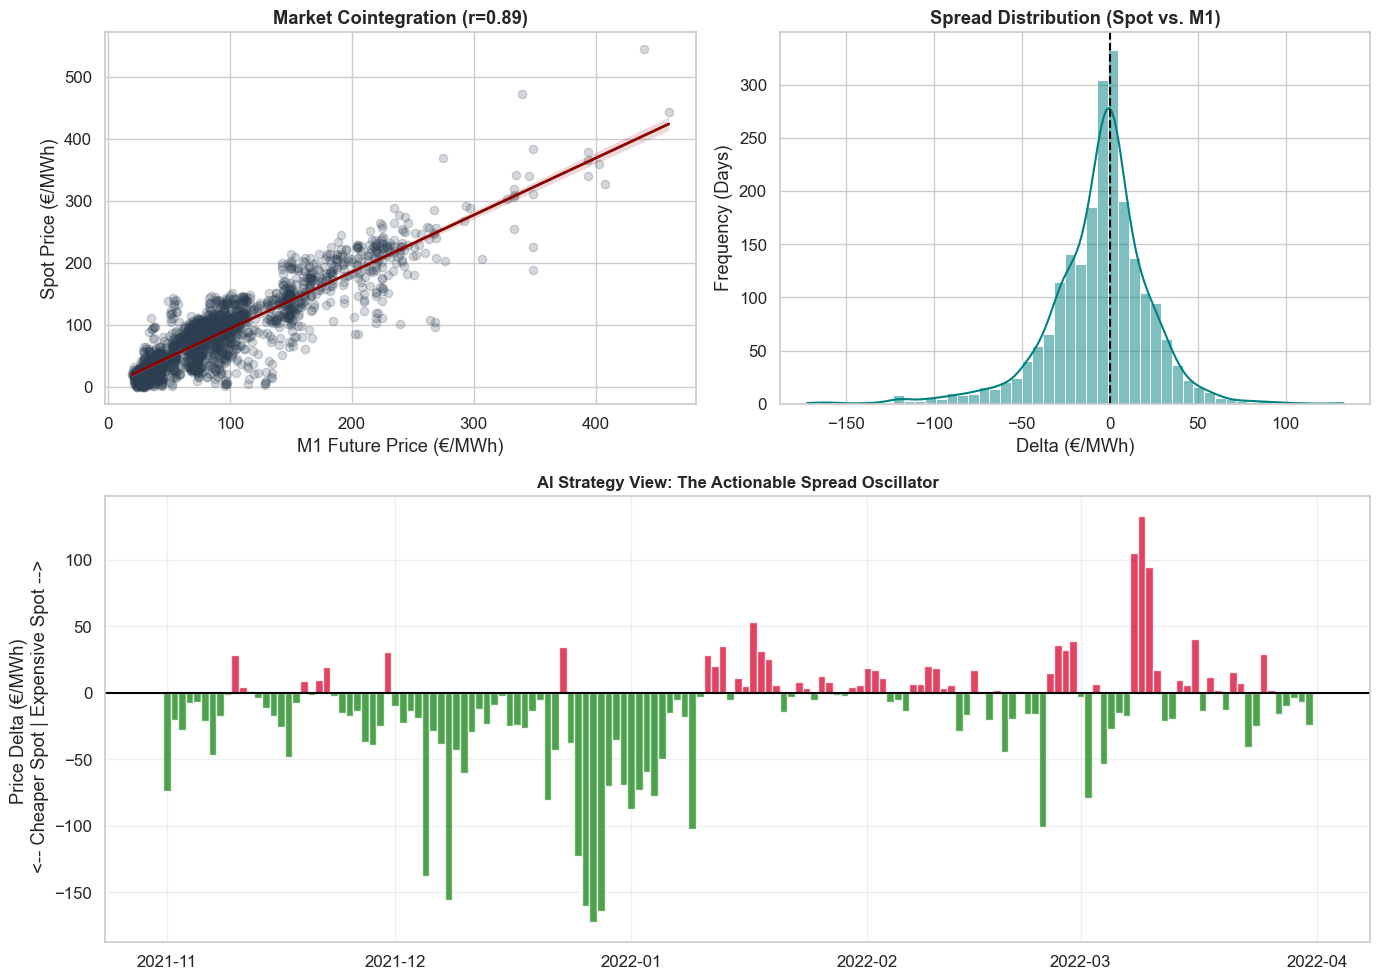

📊 Validated Pearson Correlation (Spot vs. M1 Future): 0.893


In [17]:
plot_cointegration_and_oscillator(df_master)


### 4.1.2 The Physical Drivers: Wind and Temperature Regimes
The energy price in the Iberian market is heavily dictated by two primary meteorological regimes:

**A. Wind Suppression Effect**
As shown in the visualization below, there is a clear inverse relationship between wind speed and price.
* **Observation:** High wind speed episodes consistently trigger "price collapses" due to the zero-marginal cost of renewable generation. As wind generation increases, more expensive thermal plants (gas/coal) are pushed out of the merit order. 
* **Engineering Requirement:** This confirms the need for a **Wind Regime Flag** to warn the agent of imminent market saturation.

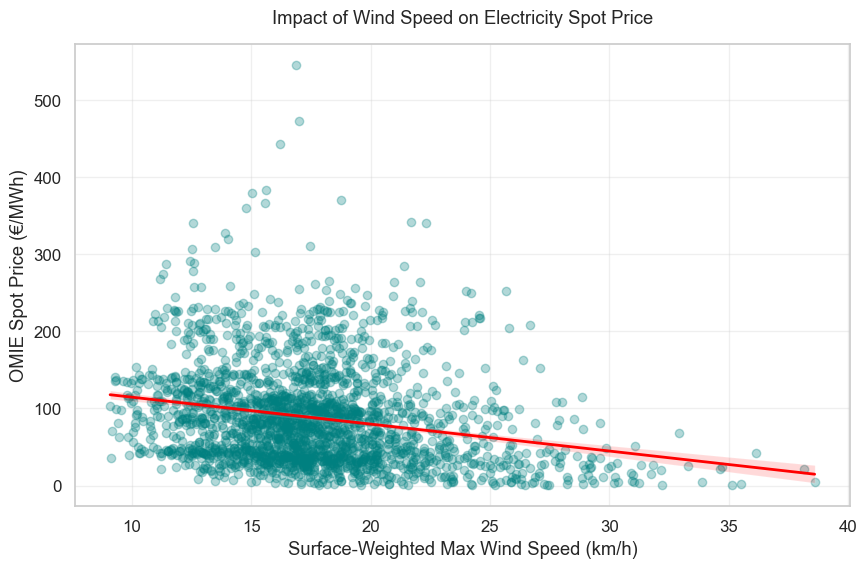

Pearson Correlation (Wind vs Price): -0.229


In [18]:
plot_wind_impact(df_master)

**B. The Thermal Paradox (U-Curve)**
As we advanced in the section: 2.4.3 Physical-Financial Coupling: Correlation Insight, the relationship between temperature and demand is non-linear, forming a characteristic "U-curve".

* **Observation:** Prices spike at both extremes (Heating demand in winter and Cooling demand in summer), with a "Comfort Zone" around 20°C where prices stabilize.
* **Engineering Requirement:** To linearize this for the AI, we will engineer **Heating Degree Days (HDD)** and **Cooling Degree Days (CDD)** features.

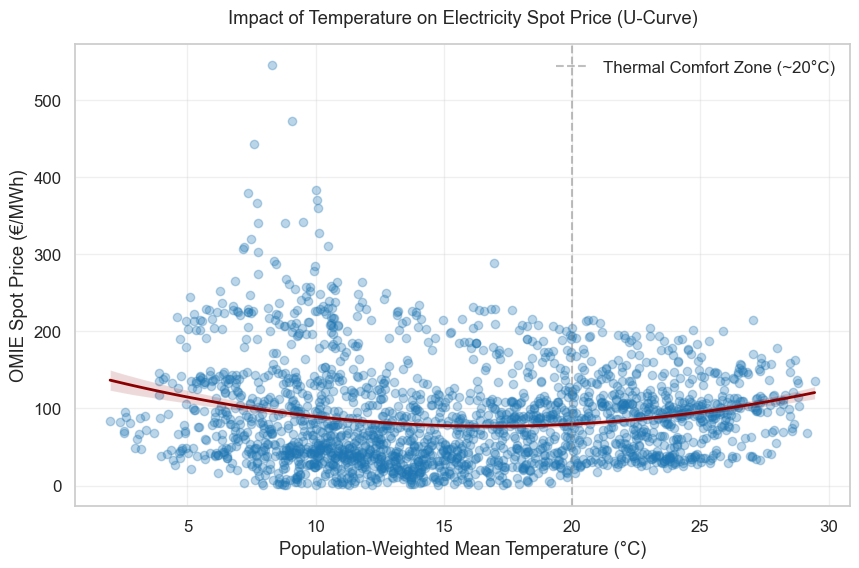

📊 Validated Pearson Correlation (Spot vs. Temperature): -0.037


In [19]:
plot_temperature_ucurve(df_master)

### 4.1.3 Correlation Matrix: Feature Redundancy Check
To ensure a lean and efficient state-space, we analyzed the global correlation matrix of our core features.

* **Finding:** While weather variables show logical couplings, they provide distinct enough signals to be kept. This matrix serves as the blueprint for our final feature selection.

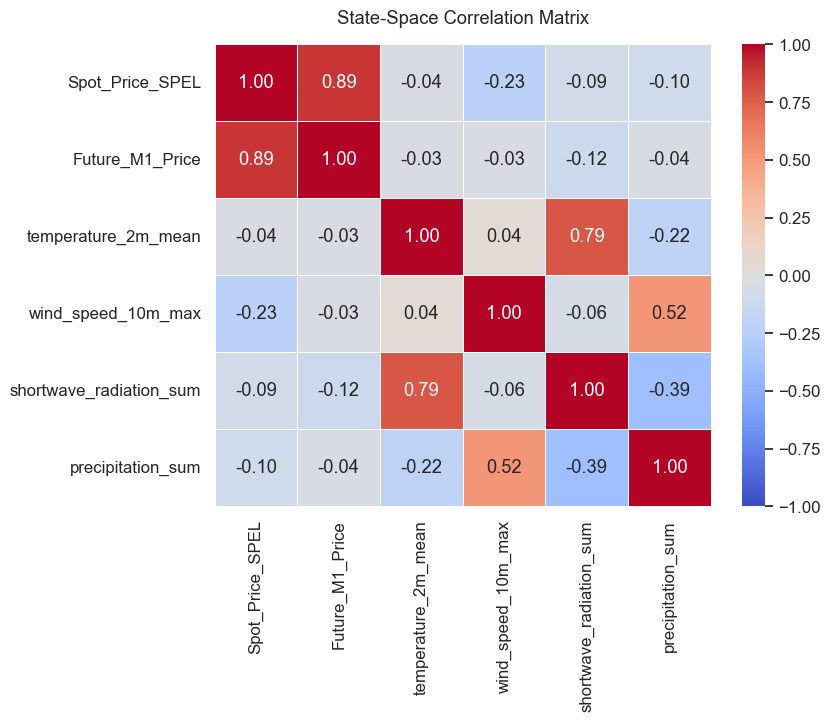

In [20]:
plot_state_space_heatmap(df_master)

### 4.2 Engineering the AI Memory & Physical Triggers
Reinforcement Learning models natively operate under the **Markov Property**. To satisfy the **Markov Decision Process (MDP)** requirements, the state at time $t$ must contain all necessary information for optimal decision-making. To achieve this, we implement a "Master Mix" strategy that embeds both historical memory and market foresight into the agent's observation space.

#### 4.2.1 Deterministic vs. Stochastic Information (Market Logic)
To simulate the agent's real-world operational environment, a critical distinction is made regarding the availability of future information in the Iberian Market (OMIE):
* **Deterministic Spot Price ($t+1$):** The Day-Ahead auction results for tomorrow are published at 13:00 CET today. Therefore, any operational decision made after this time considers the $D+1$ price as a **known constant**, not an estimate.
* **Stochastic Weather ($t+1$ to $t+3$):** Meteorological conditions remain uncertain. We simulate this by providing "clouded" forecasts—realized future values with added Gaussian noise that increases with the forecast horizon (5%, 10%, and 15%).

#### 4.2.2 The Physical Triggers (Regimes & Stress)
Following our EDA findings, we engineered synthetic predictors to linearize the market's response to weather:
* **Thermal Stress:** We transformed raw temperature into **Heating Degree Days (HDD)** and **Cooling Degree Days (CDD)** using the European standard 20°C baseline.
* **Renewable Regimes:** We introduced a `High_Wind_Flag` to explicitly signal impending zero-marginal-cost generation and price collapses.

#### 4.2.3 The Mathematical Memory (Lags & Rolling)
To overcome the Markov Property's lack of historical context, we engineered structural memories:
* **Temporal Lags ($t-1$ to $t-7$):** Capturing immediate daily shocks and weekly seasonality.
* **Rolling Statistics & Volatility:** 7-day and 14-day moving averages and standard deviations to define short-term trends and quantify market risk.

#### 4.2.4 The Financial Spread
Finally, we engineered the `Spot_M1_Spread` (Spot Price - M1 Future Price). This acts as the direct "reward proxy" signal, explicitly showing the agent the real-time premium or discount of the physical market versus the financial baseline.
* **Clarification:** This feature does not measure historical prediction error; rather, it measures the real-time **Term Structure** of the market (Contango vs. Backwardation).

In [21]:
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import the modular functions.
from src.features.build_domain_features import build_domain_features
from src.features.build_feature_matrix import build_feature_matrix

# Apply Domain-Driven Distillation & Foresight.
df_domain = build_domain_features(df_master)

# Generate Mathematical Memory (Lags & Rolling Stats).
# Note: We do NOT use dropna() here to preserve row density for Feature Selection later.
df_final = build_feature_matrix( df=df_domain, use_time_features=True, use_lag_features=True, use_rolling_features=True, use_future_features=True, save=False)

# Export to the processed data layer.
MODELING_DATASET_FILE = PROJECT_ROOT / "data" / "processed" / "modeling_dataset.csv"
MODELING_DATASET_FILE.parent.mkdir(parents=True, exist_ok=True)
df_final.to_csv(MODELING_DATASET_FILE, index=False)

print(f"\n✅ Full Feature Matrix built. Total columns: {df_final.shape[1]}")
print(f"🚀 State-space matrix (with foresight) saved at:\n{MODELING_DATASET_FILE.relative_to(PROJECT_ROOT)}")

# Preview the engineered features (Foresight & Spread).
display(df_final[['date', 'Spot_Price_SPEL', 'Spot_Price_SPEL_t+1_known', 'Spot_M1_Spread', 'HDD_pred_t+1']].head(3))


✅ Full Feature Matrix built. Total columns: 153
🚀 State-space matrix (with foresight) saved at:
data\processed\modeling_dataset.csv


,date,Spot_Price_SPEL,Spot_Price_SPEL_t+1_known,Spot_M1_Spread,HDD_pred_t+1
0,2020-01-01,35.5400,40.0000,-9.2700,16.4598
1,2020-01-02,40.0000,39.5100,-4.8100,16.1755
2,2020-01-03,39.5100,35.6700,-5.7400,16.2981


### 4.3 Dimensionality Reduction and Feature Selection

#### 4.3.1 Objective and Academic Rationale
The previous feature engineering stage generated a high-dimensional state-space. While these variables provide rich temporal and physical context, feeding them directly into a Reinforcement Learning (RL) agent or a forecasting model introduces significant risks:
1. **The Curse of Dimensionality:** Models become prone to overfitting on noise as the feature space expands relative to the number of observations.
2. **Multicollinearity:** Highly correlated features (e.g., multiple lags of the same variable) can destabilize model weights.
3. **Numerical Instability:** Ratios and percentage changes in illiquid contracts can produce infinite values that crash training algorithms.

**Modular Project Architecture:** To ensure code reusability, maintainability, and reproducibility, the core selection logic is encapsulated in the external module `src.features.feature_selection.py`. By decoupling the analytical narrative from the underlying engineering pipeline, we ensure a clean workflow.

#### 4.3.2 Shifting the Optimization Horizon (The True Target)
In standard forecasting, models are trained to predict the next sequential step ($t+1$). However, due to the structure of the Day-Ahead Market (OMIE), the price for $t+1$ is deterministic and known by 13:00 CET on day $t$. 

If the procurement agent is deciding whether to buy today ($t$) or tomorrow ($t+1$), the optimization is purely arithmetic. The Reinforcement Learning agent's true strategic value lies in evaluating the **Stochastic Horizon**: deciding whether to delay procurement to $t+2$ or $t+3$.

Therefore, we shift our target variable to `Spot_Price_target_t+2`. The selection algorithm will evaluate which features possess the highest information gain to predict the *first truly unknown state* of the market.

#### 4.3.3 Feature Selection Methodology
We employ a multi-tier filtering strategy based on our selection module:
1. **Sparsity Filter:** Removal of features with >20% missing or infinite data.
2. **Variance Filter:** Elimination of constant features.
3. **Information Gain Filter:** Utilizing a **Random Forest Regressor** to compute permutation importance. This non-linear evaluator is critical for capturing the relationships of our engineered HDD/CDD and Wind flags.

**The Anti-Leakage Protocol:**
To prevent **Target Leakage** during the Random Forest evaluation, we must explicitly blind the algorithm to the $t+3$ horizon. If left in the dataset, the tree-based model would trivially use $t+3$ to predict $t+2$, yielding artificially high performance and destroying the validity of the feature ranking.

In [22]:
from src.features.feature_selection import select_model_features, FeatureSelectionConfig

# 1. Numerical Stability Fix
df_final = df_final.replace([np.inf, -np.inf], np.nan)

# 2. Anti-Leakage: Blind the model to the t+3 horizon
# We drop t+3 so it cannot be used to predict t+2
selection_df = df_final.drop(columns=['Spot_Price_target_t+3'], errors='ignore')

# 3. Configure the selection parameters for the Stochastic Horizon (t+2)
selection_config = FeatureSelectionConfig(target_column='Spot_Price_target_t+2', max_missing_share=0.20, min_non_null_rows=30, top_k_importance=25, random_state=42)

# 4. Run Selection
selection_results = select_model_features(df=selection_df, config=selection_config)
importance_table = selection_results["importance_table"]

print(f"✅ Selection complete. Total candidates analyzed: {len(importance_table)}")

✅ Selection complete. Total candidates analyzed: 141


#### 4.3.4 Visualizing Feature Importance
The following plot ranks features based on their information gain relative to the `t+2` target. We expect the known `t+1` price to dominate as the primary anchor, followed by a mix of autoregressive financial lags and our simulated meteorological forecasts.

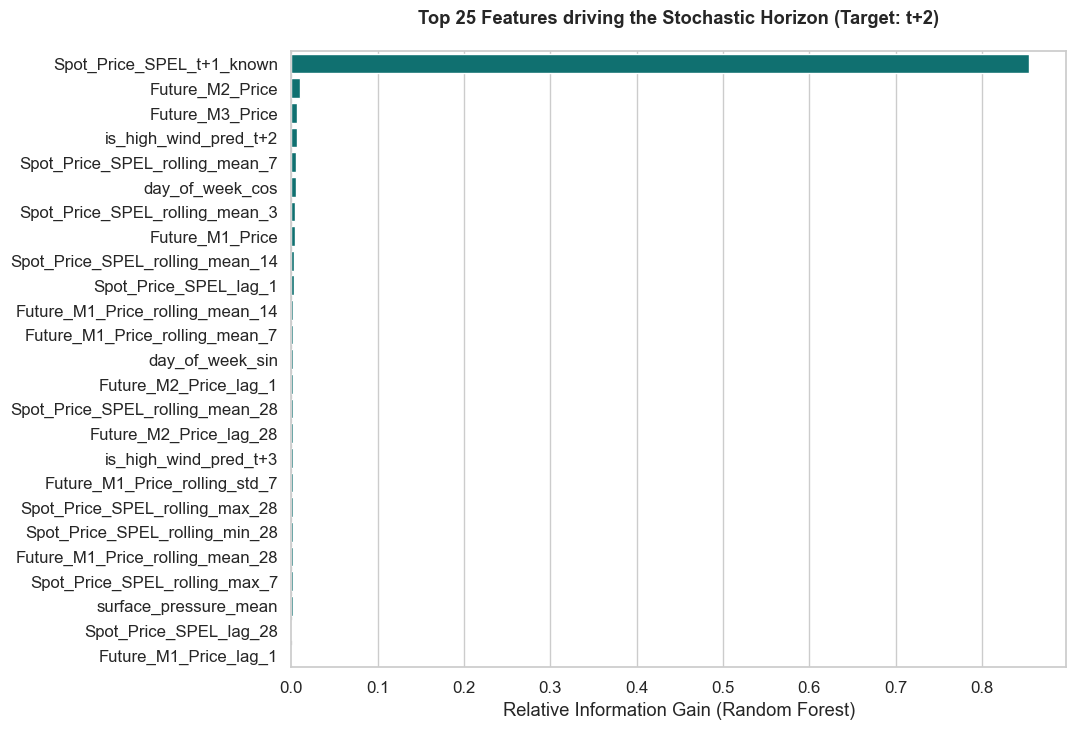

In [23]:
plot_df = importance_table.head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x='importance', y='feature_name', color='teal')
plt.title('Top 25 Features driving the Stochastic Horizon (Target: t+2)', pad=20, fontweight='bold')
plt.xlabel('Relative Information Gain (Random Forest)')
plt.ylabel('')
plt.show()

#### 4.3.5 Post-Selection Analysis & Final Compilation
The feature importance ranking is typically heavily dominated by **Financial Autoregression** (Lags of Spot and Future prices). This is a standard characteristic of high-frequency energy markets where the best predictor for $T_0$ is $T_{-1}$.

**Methodological Decision:**
Although meteorological features like `HDD` and `is_high_wind` may rank lower in raw information gain, we have **explicitly retained them** in the final state-space for the Reinforcement Learning agent.

**Rationale:**
Purely statistical selection often ignores **exogenous shocks**. While price lags explain the "trend," weather features explain the "residual volatility." Without these physical markers and our simulated $t+2$ forecasts, our RL agent would be unable to anticipate price spikes driven by thermal stress or renewable cannibalization, which are the primary sources of risk we aim to mitigate.

In [24]:
# 1. Statistical Winners (Top 18 from Random Forest)
top_algorithm_features = importance_table.head(18)['feature_name'].tolist()

# 2. Forced Domain Features (The Exogenous Shocks)
base_domain = ['HDD', 'CDD', 'is_high_wind', 'solar_intensity', 'is_solar_peak', 'is_holiday']
forecast_targets = ['solar_intensity', 'HDD', 'CDD', 'is_high_wind']
forecast_features = [f"{col}_pred_t+{day}" for col in forecast_targets for day in [1, 2, 3]]

# 3. Core Anchors & Targets (Including the blinded t+3)
anchors = ['date', 'Spot_Price_SPEL', 'Future_M1_Price', 'Spot_Price_SPEL_t+1_known', 'Spot_M1_Spread', 'Spot_Price_target_t+2', 'Spot_Price_target_t+3']

# 4. Combine and Deduplicate
final_feature_set = list(set(anchors + top_algorithm_features + base_domain + forecast_features))
final_feature_set = [f for f in final_feature_set if f in df_final.columns]

# 5. Filter and Purge NaNs
df_final_selected = df_final[final_feature_set].copy()
df_final_selected = df_final_selected.dropna().reset_index(drop=True)

# 6. Export Model-Ready Matrix
selected_dataset_path = PROJECT_ROOT / "data" / "processed" / "modeling_dataset_selected.csv"
selected_dataset_path.parent.mkdir(parents=True, exist_ok=True)
df_final_selected.to_csv(selected_dataset_path, index=False)

print(f"✅ Final State-Space Matrix exported with {df_final_selected.shape[1]} features.")
print(f"   - Target Horizon aligned to: t+2 and t+3")
print(f"   - Physical features retained to capture Exogenous Shocks.")
print(f"💾 Saved at: data/processed/{selected_dataset_path.name}")

✅ Final State-Space Matrix exported with 39 features.
   - Target Horizon aligned to: t+2 and t+3
   - Physical features retained to capture Exogenous Shocks.
💾 Saved at: data/processed/modeling_dataset_selected.csv


---

### Phase I Conclusion: The Arena is Built
The execution of Section 4.3 marks the conclusion of our Data and Feature Engineering pipeline. We have successfully transformed raw, disjointed APIs (OMIE, OMIP, OpenMeteo) into a highly refined, **MDP-compliant simulation environment**. 

Rather than simply passing a flat table of numbers to an algorithm, we have engineered a complete *State-Space*. Our Reinforcement Learning agent will enter the training phase equipped with:
* **Historical Memory:** To recognize market momentum and autoregressive trends.
* **Domain-Driven Triggers:** To anticipate exogenous physical shocks (thermal stress, wind collapses).
* **Strategic Foresight:** To differentiate between deterministic short-term pricing ($t+1$) and stochastic optimization horizons ($t+2$, $t+3$).

With the "World State" fully constructed, mathematically stabilized, and strictly safeguarded against target leakage, the data is formally handed off. 

**Next Step: Section 5 - Predictive Modeling & Risk Assessment**
In the upcoming section, we transition from data engineering to statistical modeling. We will establish a **Baseline Forecast**, deploy **Quantile Regression** to map probabilistic price boundaries, and develop a **Tail Risk Model** to quantify extreme market shocks. A rigorous model comparison will validate our predictive power.

**Looking Ahead: Section 6 - The Decision Engine**
Only once the predictive landscape and tail risks are fully mapped in Section 5 will we hand the "World State" over to our Reinforcement Learning agent in Section 6, which will act as the ultimate Decision Engine for our procurement strategy.

---

# *PONER AL FINAL:* 

---

## Statement on Responsible AI Integration & Authorship

In alignment with academic integrity guidelines and modern software engineering practices, this section details our team's responsible integration of Large Language Models (LLMs) throughout the lifecycle of this project. We have utilized Generative AI strictly as an accelerator and a formatting tool, ensuring that the core research, analytical depth, and system architecture remain entirely our original work.

### 1. The Engineering Philosophy: Efficiency vs. Accountability
In the modern corporate and industrial landscape, leveraging Generative AI is no longer a novelty; it is an expected professional competency. We approached this project with the pragmatism of working engineers: intentionally abstaining from AI tools would be an artificial limitation, hindering our efficiency and ultimately reducing the extensive scope and quality of the final deliverable. AI serves as a powerful "quality-assurance" layer, handling routine syntax and formatting faster and more accurately than a human could.

However, we are equally aware that blindly trusting an LLM is a critical operational risk. AI is far from perfect—it lacks true business context, physical intuition, and strategic foresight. Our validity and utility as engineers do not stem from writing boilerplate code or formatting Markdown tables. Our true value lies in the conceptualization of the idea, the strategic execution of the architecture, and the rigorous validation of the automated output. The AI was our assistant, but we remained the absolute directors of the project.

### 2. The Human-AI Division of Labor
To guarantee **honesty** and maintain full ownership of the intellectual deliverable, our team established a strict boundary between automated generation and strategic system design:
* **Human-Led Contributions (The Core Deliverable):** The conceptualization of the Dual-Layer Strategy, the definition of the Reinforcement Learning state/action spaces, the critical interpretation of financial metrics (e.g., Contango, Backwardation), and the mathematical modeling of the Decision Support System are exclusively human-derived.
* **AI-Assisted Contributions (The Accelerator):** LLMs were utilized across the team for specific, low-level tasks: 
    1. Optimizing Python syntax and structuring data-ingestion pipelines.
    2. Generating complex, multi-axis visualization code (`matplotlib`, `seaborn`) based on our explicit design constraints.
    3. Drafting and refining the Markdown text to ensure a high standard of academic formality.

### 3. Methodological Honesty in Drafting
Regarding the written content of this report, we want to be fully transparent: **the formal prose and Markdown structures were articulated by an LLM, but the foundational ideas were strictly dictated by our team.** Our prompting methodology was treated as a deterministic engineering task. Rather than asking an AI to "write an analysis," team members provided the LLM with raw, bulleted insights, specific numerical findings, and the logical narrative flow we wanted to convey. The AI was then tasked exclusively with translating these human conclusions into polished, self-explanatory academic English suitable for a technical and executive audience.

### 4. Ensuring Insightfulness and Human Oversight
Because LLMs process data mathematically without understanding the underlying business reality, no AI output was accepted at face value. For instance, while an AI might suggest analyzing the entire M1-M6 forward curve, it requires human **insightfulness** to override that suggestion and recognize that contracts beyond M3 act as "ghost markets" with severe liquidity risks (slippage). The depth and validity of this report stem entirely from our team actively auditing and overriding standard algorithmic suggestions to reflect real-world Iberian Market dynamics.

---